# Generic Lindblad Master Equation Solver using RK4

This notebook implements a direct matrix-form solver for a Lindblad master equation of the form

$$
\dot{\rho}= -\frac{i}{\hbar}[H,\rho]
+ \sum_i \gamma_i\left(
L_i\rho L_i^\dagger
-\frac{1}{2}\{L_i^\dagger L_i,\rho\}
\right).
$$

The aim is to expose the structure of the equation rather than to replace optimized solvers such as QuTiP `mesolve`.

Workflow:

1. Define the Hamiltonian.
2. Define the density matrix and Lindblad operators using QuTiP.
3. Choose a finite Hilbert-space cutoff when the system is infinite-dimensional.
4. Convert the master equation into a matrix-valued right-hand side.
5. Integrate using explicit fourth-order Runge--Kutta.
6. Compare against QuTiP.

## 1. Imports

QuTiP is used to construct operators cleanly. The RK4 propagation itself is done manually with NumPy arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

/home/jayarshi/miniconda3/envs/oqs/lib/python3.11/site-packages/_distutils_hack/__init__.py:53: UserWarning: Reliance on distutils from stdlib is deprecated. Users must rely on setuptools to provide the distutils module. Avoid importing distutils or import setuptools first, and avoid setting SETUPTOOLS_USE_DISTUTILS=stdlib. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


## 2. Matrix form of the Lindblad equation

We represent $\rho$, $H$, and $L_i$ as ordinary NumPy matrices.

Convention used here:

- Manual solver: collapse channels are stored as $(\gamma_i,L_i)$.
- QuTiP: collapse channels are supplied as $\sqrt{\gamma_i}L_i$.
**Right-hand side of the Lindblad master equation**

| Parameter      | Type          | Description                                                                                               |
| -------------- | ------------- | --------------------------------------------------------------------------------------------------------- |
| `rho`          | `ndarray`     | Density matrix.                                                                                           |
| `H`            | `ndarray`     | Hamiltonian matrix.                                                                                       |
| `collapse_ops` | `list[tuple]` | List of `(gamma, L)` pairs, where `gamma` is the decay/dissipation rate and `L` is the Lindblad operator. |
| `hbar`         | `float`       | Reduced Planck constant. Default is `1`.                                                                  |

### Returns

| Name   | Type      | Description               |
| ------ | --------- | ------------------------- |
| `drho` | `ndarray` | Time derivative of `rho`. |

In [2]:
def lindblad_rhs_matrix(rho, H, collapse_ops, hbar=1.0):
    drho = (-1j / hbar) * (H @ rho - rho @ H)

    for gamma, L in collapse_ops:
        Ldag = L.conj().T
        LdagL = Ldag @ L
        drho += gamma * (L @ rho @ Ldag - 0.5 * (LdagL @ rho + rho @ LdagL))

    return drho

## 3. RK4 integrator

The master equation is a first-order linear differential equation for the density matrix. We keep the density matrix in matrix form instead of explicitly flattening it into a vector.

After each RK4 step, we optionally apply a numerical cleanup:

$$
\rho \rightarrow \frac{1}{2}(\rho+\rho^\dagger),
\qquad
\rho \rightarrow \frac{\rho}{\mathrm{Tr}\rho}.
$$

This suppresses small numerical drift in Hermiticity and trace caused by finite-step integration.

In [3]:
def rk4_lindblad(rho0, H, collapse_ops, tlist, hbar=1.0, cleanup=True):
    rho = rho0.astype(complex).copy()
    dim = rho.shape[0]

    rhos = np.zeros((len(tlist), dim, dim), dtype=complex)
    rhos[0] = rho

    for n in range(len(tlist) - 1):
        dt = tlist[n + 1] - tlist[n]

        k1 = lindblad_rhs_matrix(rho, H, collapse_ops, hbar)
        k2 = lindblad_rhs_matrix(rho + 0.5 * dt * k1, H, collapse_ops, hbar)
        k3 = lindblad_rhs_matrix(rho + 0.5 * dt * k2, H, collapse_ops, hbar)
        k4 = lindblad_rhs_matrix(rho + dt * k3, H, collapse_ops, hbar)

        rho = rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        if cleanup:
            rho = 0.5 * (rho + rho.conj().T)
            rho = rho / np.trace(rho)

        rhos[n + 1] = rho

    return rhos

## 4. Example: damped harmonic oscillator

We test the generic solver on a damped quantum harmonic oscillator,

$$
H = \omega a^\dagger a.
$$

For a thermal bath, the collapse channels are

$$
(\gamma_1,L_1)=\left(\kappa(\bar n+1),a\right),
\qquad
(\gamma_2,L_2)=\left(\kappa\bar n,a^\dagger\right).
$$

The oscillator Hilbert space is infinite-dimensional, so we impose a finite cutoff $N$.

In [4]:
# Hilbert-space cutoff
N = 20

# Physical parameters
omega = 1.0
kappa = 0.1
n_th = 0.0

# QuTiP operators
a = qt.destroy(N)
adag = a.dag()
num = adag * a

H_q = omega * adag * a
rho0_q = qt.fock_dm(N, 5)

# Manual convention: (gamma, L)
collapse_q = [
    (kappa * (n_th + 1.0), a),
    (kappa * n_th, adag),
]

# Convert QuTiP objects to NumPy arrays
H = H_q.full()
rho0 = rho0_q.full()
collapse_ops = [(gamma, L.full()) for gamma, L in collapse_q]

# Time grid
tlist = np.linspace(0.0, 50.0, 1000)

## 5. Manual RK4 propagation

In [5]:
rhos = rk4_lindblad(rho0, H, collapse_ops, tlist)

## 6. Observables

The natural observable is the oscillator occupation number,

$$
\langle n(t)\rangle=\mathrm{Tr}[\rho(t)a^\dagger a].
$$

In [6]:
num_mat = num.full()

n_expect_rk4 = np.array([
    np.real(np.trace(rho @ num_mat))
    for rho in rhos
])

trace_error = np.array([
    abs(np.trace(rho) - 1.0)
    for rho in rhos
])

hermiticity_error = np.array([
    np.linalg.norm(rho - rho.conj().T)
    for rho in rhos
])

## 7. QuTiP comparison

For QuTiP, the collapse operator contains the square root of the rate.

In [7]:
c_ops_qutip = [
    np.sqrt(gamma) * L
    for gamma, L in collapse_q
    if gamma > 0.0
]

result = qt.mesolve(
    H=H_q,
    rho0=rho0_q,
    tlist=tlist,
    c_ops=c_ops_qutip,
    e_ops=[num]
)

n_expect_qutip = np.array(result.expect[0])

## 8. Occupation dynamics

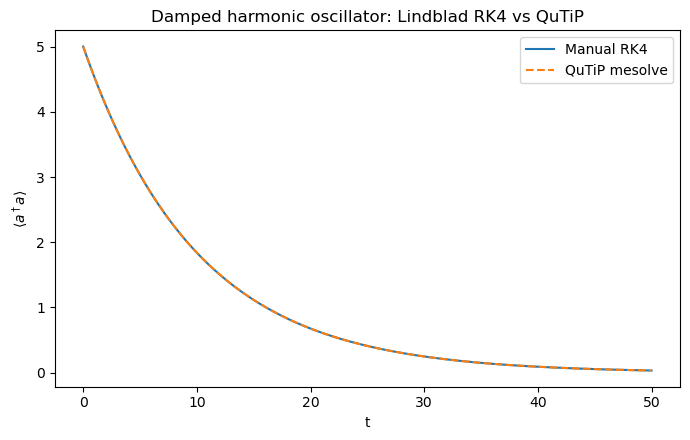

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(tlist, n_expect_rk4, label="Manual RK4")
plt.plot(tlist, n_expect_qutip, "--", label="QuTiP mesolve")
plt.xlabel("t")
plt.ylabel(r"$\langle a^\dagger a \rangle$")
plt.title("Damped harmonic oscillator: Lindblad RK4 vs QuTiP")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Numerical consistency checks

A physical density matrix should remain trace-one and Hermitian. RK4 does not automatically preserve these structures exactly at finite step size, so these diagnostics are useful.

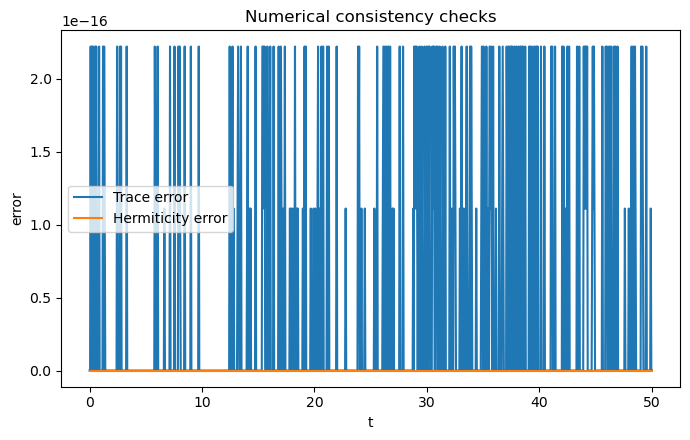

In [9]:
plt.figure(figsize=(7, 4.5))
plt.plot(tlist, trace_error, label="Trace error")
plt.plot(tlist, hermiticity_error, label="Hermiticity error")
plt.xlabel("t")
plt.ylabel("error")
plt.title("Numerical consistency checks")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Error relative to QuTiP

The comparison error is

$$
\Delta n(t)=|\langle n(t)\rangle_{\mathrm{RK4}}-\langle n(t)\rangle_{\mathrm{QuTiP}}|.
$$

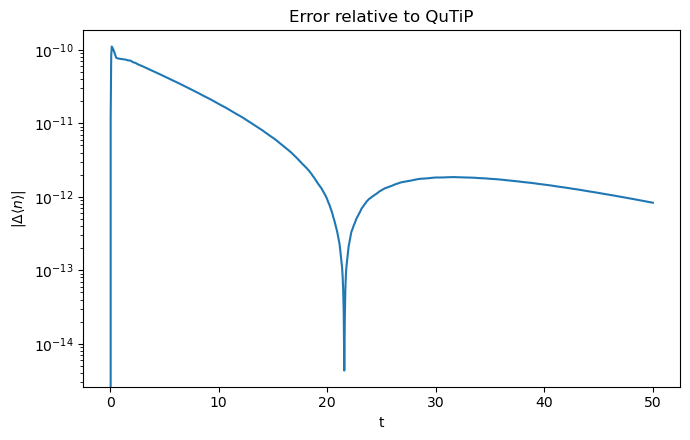

Maximum error: 1.1090417473269554e-10


In [10]:
err = np.abs(n_expect_rk4 - n_expect_qutip)

plt.figure(figsize=(7, 4.5))
plt.semilogy(tlist, err)
plt.xlabel("t")
plt.ylabel(r"$|\Delta \langle n \rangle|$")
plt.title("Error relative to QuTiP")
plt.tight_layout()
plt.show()

print("Maximum error:", np.max(err))

## 11. Cutoff convergence

For infinite-dimensional systems, the Hilbert space cutoff $N$ must be checked by increasing it until observables stop changing appreciably.

In [11]:
def run_damped_oscillator_cutoff(N, n0=5, omega=1.0, kappa=0.1, n_th=0.0, tlist=None):
    if tlist is None:
        tlist = np.linspace(0.0, 50.0, 1000)

    a = qt.destroy(N)
    adag = a.dag()
    num = adag * a

    H_q = omega * adag * a
    rho0_q = qt.fock_dm(N, n0)

    collapse_q = [
        (kappa * (n_th + 1.0), a),
        (kappa * n_th, adag),
    ]

    H = H_q.full()
    rho0 = rho0_q.full()
    collapse_ops = [(gamma, L.full()) for gamma, L in collapse_q]

    rhos = rk4_lindblad(rho0, H, collapse_ops, tlist)
    num_mat = num.full()

    n_expect = np.array([
        np.real(np.trace(rho @ num_mat))
        for rho in rhos
    ])

    return n_expect

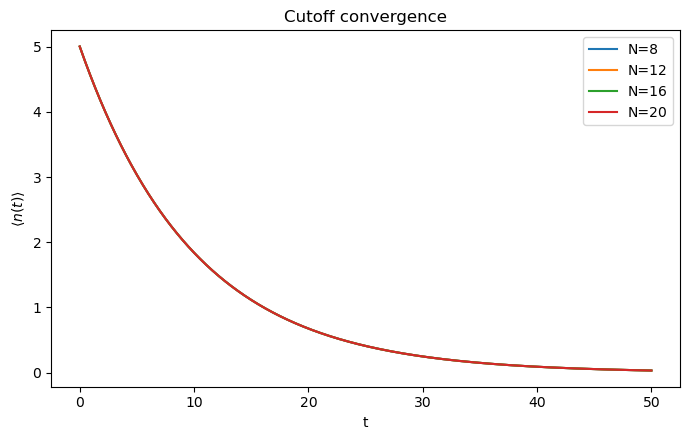

In [12]:
cutoffs = [8, 12, 16, 20]

plt.figure(figsize=(7, 4.5))
for Nc in cutoffs:
    n_exp = run_damped_oscillator_cutoff(Nc, n0=5, tlist=tlist)
    plt.plot(tlist, n_exp, label=f"N={Nc}")

plt.xlabel("t")
plt.ylabel(r"$\langle n(t)\rangle$")
plt.title("Cutoff convergence")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Final remarks

This notebook writes the Lindblad equation directly as a coupled first-order matrix ODE. It is useful for understanding the structure of GKSL dynamics and for checking sign/rate conventions.

For production-scale calculations, QuTiP's built-in solvers are usually preferable because they are optimized, adaptive, and extensively tested.